In [1]:
import pandas as pd

In [2]:
pd.read_csv("processed-data/defaulter.csv")

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1
...,...,...,...,...,...,...,...,...,...,...,...
14573,11250.000000,1893.150000,12.157324,1,2.0,0.501213,0.591424,0.513171,0.117428,545.0,0
14574,33750.000000,4900.050000,17.000000,0,3.0,0.501213,0.563311,0.513171,0.016500,502.0,1
14575,38070.000000,2878.650000,12.157324,0,3.0,0.501213,0.748159,0.513171,0.070100,699.0,0
14576,16855.246324,5154.300000,7.000000,0,2.0,0.501213,0.559936,0.513171,0.030600,1323.0,0


In [3]:
dados=pd.read_csv("processed-data/defaulter.csv")

In [4]:
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [6]:
round(dados["inadimplente"].value_counts(normalize=True)*100, 2)

inadimplente
0    67.65
1    32.35
Name: proportion, dtype: float64

In [7]:
x=dados.drop("inadimplente", axis=1)
y=dados["inadimplente"]

In [8]:
from sklearn.model_selection import train_test_split
RANDOM_STATE=42
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
modelo_decision_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelo_decision_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [11]:
from sklearn.metrics import recall_score
recall_decision_tree = recall_score(y_test, modelo_decision_tree.predict(x_test))
print(f"Recall do DT: {recall_decision_tree:.3f}")

Recall do DT: 0.143


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression())
logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [15]:
recall_logistic_regression = recall_score(y_test, logistic_pipeline.predict(x_test))
print(f"Recall da LR: {recall_logistic_regression:.3f}")

Recall da LR: 0.253


In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
import numpy as np

param_grid_dt = {
   "criterion": ["gini", "entropy"],
   "max_depth": np.linspace(6, 12, 4, dtype=int),
   "min_samples_split": np.linspace(5, 20, 4, dtype=int),
   "min_samples_leaf": np.linspace(5, 20, 4, dtype=int),
   "max_features": ["sqrt", "log2"],
   "splitter": ["best", "random"]
}

In [22]:
from sklearn.model_selection import StratifiedKFold

cv=StratifiedKFold(shuffle=True, random_state=RANDOM_STATE)

dt_grid_search=GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
             param_grid=param_grid_dt,
             scoring="recall",
             n_jobs=-1,
             cv=cv)

dt_grid_search.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 6,  8, 10, 12]),
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': array([ 5, 10, 15, 20]),
                         'min_samples_split': array([ 5, 10, 15, 20]),
                         'splitter': ['best', 'random']},
             scoring='recall')

In [23]:
dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [24]:
dt_grid_search.cv_results_

{'mean_fit_time': array([0.07276297, 0.04775496, 0.02671738, 0.00605016, 0.01518192,
        0.00758429, 0.02482939, 0.01210437, 0.02140832, 0.00906162,
        0.01594748, 0.00805745, 0.01449032, 0.00781169, 0.01691809,
        0.00778918, 0.01502128, 0.00665717, 0.0161046 , 0.00860205,
        0.01469646, 0.00808949, 0.01678061, 0.01062994, 0.01692238,
        0.01036782, 0.01599154, 0.0068296 , 0.01711745, 0.00945306,
        0.0194622 , 0.01204529, 0.02091317, 0.01192942, 0.02138672,
        0.0099443 , 0.01788673, 0.00868464, 0.01920028, 0.00956035,
        0.02193646, 0.0129262 , 0.02001514, 0.01046128, 0.02216625,
        0.0096066 , 0.02007942, 0.00978956, 0.01931062, 0.00924058,
        0.01820669, 0.01006403, 0.0206389 , 0.01029353, 0.01800604,
        0.00873499, 0.01883192, 0.0094676 , 0.01954756, 0.00906625,
        0.01777143, 0.00976276, 0.01994071, 0.00903873, 0.02406173,
        0.0100853 , 0.02121167, 0.0116457 , 0.02300544, 0.01139674,
        0.02666178, 0.01310668,

In [25]:
pd.DataFrame(dt_grid_search.cv_results_).sort_values("rank_test_score").head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
246,0.034417,0.009368,0.009627,0.000682,gini,12,log2,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
244,0.040748,0.013762,0.008506,0.001380,gini,12,log2,15,15,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
242,0.027491,0.001344,0.007725,0.001418,gini,12,log2,15,10,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
240,0.031511,0.008742,0.011806,0.008652,gini,12,log2,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
214,0.037654,0.012823,0.010127,0.002798,gini,12,sqrt,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
212,0.037121,0.009050,0.013536,0.004715,gini,12,sqrt,15,15,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
210,0.039965,0.012100,0.008299,0.000809,gini,12,sqrt,15,10,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
208,0.034585,0.005957,0.010845,0.001629,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
438,0.049235,0.009242,0.012901,0.005072,entropy,10,log2,15,20,best,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.232595,0.174051,0.316456,0.319620,0.250000,0.258544,0.054717,9
436,0.050105,0.019010,0.008951,0.002028,entropy,10,log2,15,15,best,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.232595,0.174051,0.316456,0.319620,0.250000,0.258544,0.054717,9


In [26]:
df_cv_results_dt = pd.DataFrame(dt_grid_search.cv_results_)

In [27]:
df_cv_results_dt.sort_values("rank_test_score").head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
246,0.034417,0.009368,0.009627,0.000682,gini,12,log2,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
244,0.040748,0.013762,0.008506,0.001380,gini,12,log2,15,15,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
242,0.027491,0.001344,0.007725,0.001418,gini,12,log2,15,10,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
240,0.031511,0.008742,0.011806,0.008652,gini,12,log2,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
214,0.037654,0.012823,0.010127,0.002798,gini,12,sqrt,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
212,0.037121,0.009050,0.013536,0.004715,gini,12,sqrt,15,15,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
210,0.039965,0.012100,0.008299,0.000809,gini,12,sqrt,15,10,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
208,0.034585,0.005957,0.010845,0.001629,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
438,0.049235,0.009242,0.012901,0.005072,entropy,10,log2,15,20,best,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.232595,0.174051,0.316456,0.319620,0.250000,0.258544,0.054717,9
436,0.050105,0.019010,0.008951,0.002028,entropy,10,log2,15,15,best,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.232595,0.174051,0.316456,0.319620,0.250000,0.258544,0.054717,9


In [28]:
df_cv_results_dt.loc[[dt_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.034585,0.005957,0.010845,0.001629,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


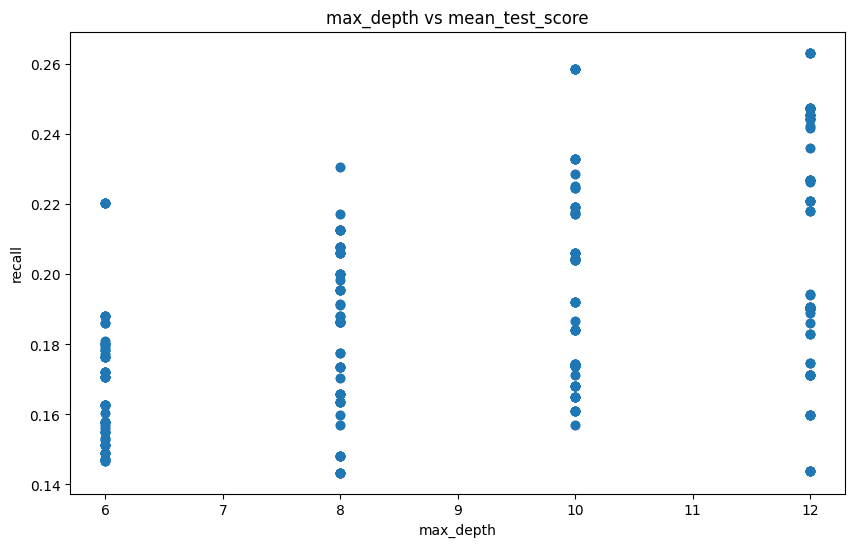

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_dt["param_max_depth"], df_cv_results_dt["mean_test_score"])

plt.title("max_depth vs mean_test_score")
plt.xlabel("max_depth")
plt.ylabel("recall")
plt.show()

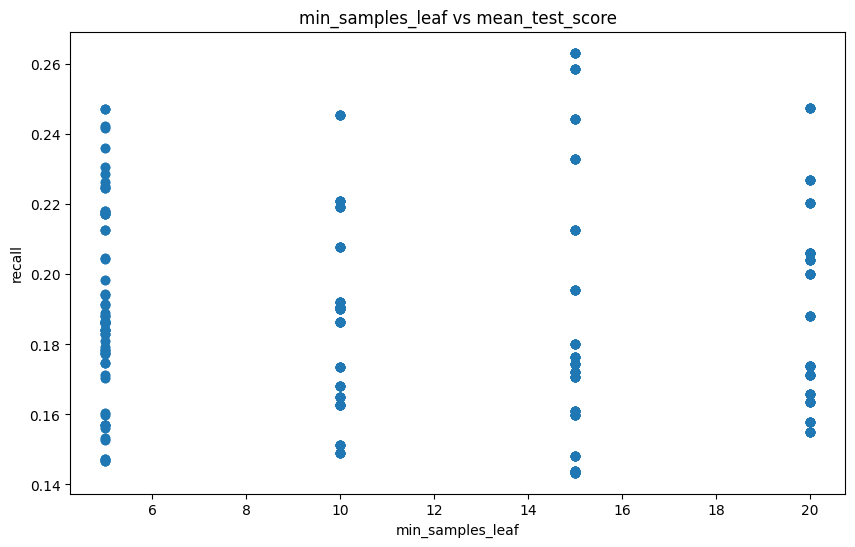

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_cv_results_dt["param_min_samples_leaf"], df_cv_results_dt["mean_test_score"])

plt.title("min_samples_leaf vs mean_test_score")
plt.xlabel("min_samples_leaf")
plt.ylabel("recall")
plt.show()